# Noise Residual Stream for Deepfake Detection (GPU-Accelerated Pipeline)

This notebook implements a binary classifier using Spatial Rich Model (SRM) filters to extract noise residuals, followed by an EfficientNetV2-S backbone for spatial feature learning.

**Workflow:**
1. Load raw RGB tensors (precomputed: resize + to_tensor only)
2. Apply augmentation (H/V flips + color/JPEG compression for BOTH real and fake images) → SRM filtering on 3-channel RGB → truncate noise to [-3, 3] (NO ImageNet normalization)
3. Train EfficientNetV2-S with inverted 3-tier differential learning rates and label smoothing
4. Evaluate with comprehensive performance metrics

**Key Components:**
- **100% GPU Pipeline**: All augmentation, SRM, and truncation operations on GPU
- **SRM Filters**: Fixed 5x5 kernel that extracts high-frequency noise patterns from 3-channel RGB images
- **EfficientNetV2-S**: Pre-trained efficient CNN backbone (all layers trainable with inverted 3-tier learning rates)
- **Symmetric Augmentations**: Color jitter and JPEG compression applied to BOTH real and fake images (30% probability)
- **Anti-Overfitting**: Label smoothing (0.0→0.05, 1.0→0.95) + inverted differential learning rates

**Training Strategy:**
- **All Layers Unfrozen**: Entire model is trainable with inverted differential learning rates
- **Early features (blocks 0-4)**: lr=1e-4 (fast adaptation to truncated noise)
- **Late features (blocks 5+)**: lr=5e-5 (moderate adaptation of mid-to-high level features)
- **Classifier**: lr=1e-4 (aggressive training of task-specific head)

**Methodological Fixes:**
- ✓ **Symmetric Augmentations**: Prevents shortcut learning by applying color/JPEG to both classes
- ✓ **3-Channel SRM**: Preserves chrominance noise artifacts (no grayscale conversion)
- ✓ **Truncation Instead of Normalization**: Respects zero-mean Laplacian noise distribution
- ✓ **Inverted Learning Rates**: Early layers adapt faster to noise (not RGB textures)

**Performance Analysis:**
- Comprehensive metrics (Accuracy, Precision, Recall, F1, AUC-ROC)
- Confusion matrices and classification reports
- ROC curves and Precision-Recall curves

In [1]:
import os
import sys
import warnings
import numpy as np
from pathlib import Path
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torchvision import datasets
import kornia.augmentation as K

from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, auc, roc_auc_score, precision_recall_curve, 
    average_precision_score, f1_score,
    precision_score, recall_score
)

# Suppress torch.meshgrid warning from kornia's JPEG compression
warnings.filterwarnings('ignore', category=UserWarning, message='.*torch.meshgrid.*')

sys.path.append('..')
from utils.models import SRMConv2d, NoiseResNet, NoiseEfficientNet

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Step 1: Define Noise-EfficientNet Model

In [2]:
print("NoiseEfficientNet model imported successfully from utils.models!")
print("\nArchitecture:")
print("  1. RAW RGB Input (224x224) - loaded from precomputed tensors")
print("  2. GPU Augmentation: H/V flips + color/JPEG compression (30% probability for BOTH real and fake)")
print("  3. GPU SRM Filter: Fixed 5x5 filter extracts 3-channel noise residuals from RGB")
print("  4. Truncate Noise: Clamp noise residuals to [-3, 3] (NO ImageNet normalization)")
print("  5. EfficientNetV2-S: Pre-trained on ImageNet (all layers trainable)")
print("  6. Final Classifier: Dropout(0.5) + Linear(1280, 1)")
print("\nTraining Strategy:")
print("  - All layers UNFROZEN (entire model trainable)")
print("  - INVERTED 3-Tier Differential Learning Rates:")
print("    * Early features (blocks 0-4): lr=1e-4 (fast adaptation to noise)")
print("    * Late features (blocks 5+): lr=5e-5")
print("    * Classifier: lr=1e-4")
print("  - Augmentations: Applied to BOTH real and fake images (30% probability)")
print("  - Label Smoothing: 0.0→0.05, 1.0→0.95 (training only)")
print("  - 100% GPU Operations: Zero CPU overhead in training loop")
print("\nKey Methodological Fixes:")
print("  ✓ Symmetric augmentations prevent shortcut learning")
print("  ✓ 3-channel SRM preserves chrominance noise artifacts")
print("  ✓ Truncation respects zero-mean Laplacian noise distribution")
print("  ✓ Early layers adapt faster to noise (not RGB textures)")

NoiseEfficientNet model imported successfully from utils.models!

Architecture:
  1. RAW RGB Input (224x224) - loaded from precomputed tensors
  2. GPU Augmentation: H/V flips + color/JPEG compression (30% probability for BOTH real and fake)
  3. GPU SRM Filter: Fixed 5x5 filter extracts 3-channel noise residuals from RGB
  4. Truncate Noise: Clamp noise residuals to [-3, 3] (NO ImageNet normalization)
  5. EfficientNetV2-S: Pre-trained on ImageNet (all layers trainable)
  6. Final Classifier: Dropout(0.5) + Linear(1280, 1)

Training Strategy:
  - All layers UNFROZEN (entire model trainable)
  - INVERTED 3-Tier Differential Learning Rates:
    * Early features (blocks 0-4): lr=1e-4 (fast adaptation to noise)
    * Late features (blocks 5+): lr=5e-5
    * Classifier: lr=1e-4
  - Augmentations: Applied to BOTH real and fake images (30% probability)
  - Label Smoothing: 0.0→0.05, 1.0→0.95 (training only)
  - 100% GPU Operations: Zero CPU overhead in training loop

Key Methodological Fixes

## Step 2: Precompute RAW RGB Tensors (No Normalization, No SRM)

In [3]:
# Check if precomputation is needed
output_dir = '../data/image_RGB'
if os.path.exists(output_dir) and len(os.listdir(output_dir)) > 0:
    print(f"✓ Precomputed RGB tensors already exist at {output_dir}")
    print("Skipping precomputation step.")
else:
    print("Starting RGB tensor precomputation...")
    print("Note: Saving RAW RGB tensors (no normalization, no SRM filtering)")
    
    # Define preprocessing transforms - ONLY resize and convert to tensor
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    
    # Define source and target directories
    splits = ['train', 'val', 'test']
    classes = ['fake', 'real']
    
    input_base = '../data/image'
    output_base = '../data/image_RGB'
    
    # Create output directories
    for split in splits:
        for cls in classes:
            os.makedirs(os.path.join(output_base, split, cls), exist_ok=True)
    
    # Process each split
    total_processed = 0
    for split in splits:
        print(f"\nProcessing {split} set...")
        
        for cls in classes:
            input_dir = os.path.join(input_base, split, cls)
            output_dir_cls = os.path.join(output_base, split, cls)
            
            # Skip if directory doesn't exist
            if not os.path.exists(input_dir):
                print(f"  Warning: {input_dir} does not exist, skipping...")
                continue
            
            # Get all image files
            image_files = [f for f in os.listdir(input_dir) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
            
            print(f"  Processing {len(image_files)} {cls} images...")
            
            for img_file in tqdm(image_files, desc=f"  {split}/{cls}"):
                # Load and preprocess image
                img_path = os.path.join(input_dir, img_file)
                img = Image.open(img_path).convert('RGB')
                img_tensor = preprocess(img)  # Only resize + to_tensor (no normalization)
                
                # Save as .pt file
                output_path = os.path.join(output_dir_cls, 
                                          os.path.splitext(img_file)[0] + '.pt')
                torch.save(img_tensor, output_path)
                
                total_processed += 1
    
    print(f"\n✓ Precomputation complete! Processed {total_processed} images.")
    print(f"✓ Raw RGB tensors saved to {output_base}")

✓ Precomputed RGB tensors already exist at ../data/image_RGB
Skipping precomputation step.


## Step 3: Define Custom Dataset for Precomputed RGB Tensors

In [4]:
from utils.dataset import PrecomputedSRMDataset

# Create datasets (now loading RAW RGB tensors)
print("\n=== Creating Datasets ===")
train_dataset = PrecomputedSRMDataset('../data/image_RGB/train')
val_dataset = PrecomputedSRMDataset('../data/image_RGB/val')
test_dataset = PrecomputedSRMDataset('../data/image_RGB/test')

print("\n=== Dataset Summary ===")
print(f"Train: {len(train_dataset)} images")
print(f"Validation: {len(val_dataset)} images")
print(f"Test: {len(test_dataset)} images")


=== Creating Datasets ===
Loaded 27960 precomputed RGB tensors from ../data/image_RGB/train
  Fake (Class 0): 13990
  Real (Class 1): 13970
Loaded 5991 precomputed RGB tensors from ../data/image_RGB/val
  Fake (Class 0): 2996
  Real (Class 1): 2995
Loaded 5981 precomputed RGB tensors from ../data/image_RGB/test
  Fake (Class 0): 2992
  Real (Class 1): 2989

=== Dataset Summary ===
Train: 27960 images
Validation: 5991 images
Test: 5981 images


## Step 4: Create DataLoaders

In [5]:
# Hyperparameters
BATCH_SIZE = 64
NUM_EPOCHS = 50

# Create dataloaders with pin_memory for faster GPU transfer
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f'\n=== DataLoaders Created ===')
print(f'Train batches: {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')


=== DataLoaders Created ===
Train batches: 437
Validation batches: 94
Test batches: 94


## Step 5: Define Evaluation Metrics Functions

In [6]:
def compute_detailed_metrics(model, data_loader, device, srm_layer, dataset_name="Dataset"):
    """
    Compute comprehensive evaluation metrics including:
    - Accuracy, Precision, Recall, F1-Score
    - Confusion Matrix
    - ROC-AUC and Precision-Recall AUC
    - Per-class performance
    
    Label Convention: Dataset uses Fake=0, Real=1
    Prediction Convention: Model predicts with Fake=0 as positive class for deepfake detection
    
    Key Changes:
    - NO grayscale conversion - SRM processes 3-channel RGB directly
    - NO ImageNet normalization - truncate noise residuals to [-3, 3]
    - Inverted labels/predictions to treat Fake (0) as positive class
    """
    model.eval()
    srm_layer.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(data_loader, desc=f"Evaluating {dataset_name}"):
            # Move to GPU
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).float()
            
            # Scale to [0, 255] range for SRM processing
            inputs = inputs * 255.0
            
            # GPU Extract Noise from 3-channel RGB (NO grayscale conversion)
            inputs = srm_layer(inputs)
            
            # Truncate noise residuals to [-3, 3]
            inputs = torch.clamp(inputs, min=-3.0, max=3.0)
            
            # Normalize to [-1, 1] range for EfficientNet
            inputs = inputs / 3.0
            
            # GPU Forward Pass (3-channel noise map)
            outputs = model(inputs).squeeze(1)
            
            # Model outputs logits where high value = Real (1), low value = Fake (0)
            # Compute probability of Real class (positive class)
            probs_real = torch.sigmoid(outputs)
            # Predict Real (1) if P(Real) > 0.5, else Fake (0)
            preds = (probs_real > 0.5).float()
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs_real.cpu().numpy())
    
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    
    # Invert labels and predictions to treat Fake (0) as positive class
    inverted_labels = 1 - all_labels
    inverted_preds = 1 - all_preds
    fake_probs = 1.0 - all_probs
    
    # Calculate metrics with Fake=0 as positive class
    accuracy = (all_preds == all_labels).mean()  # Accuracy is class-agnostic
    precision = precision_score(inverted_labels, inverted_preds, zero_division=0)
    recall = recall_score(inverted_labels, inverted_preds, zero_division=0)
    f1 = f1_score(inverted_labels, inverted_preds, zero_division=0)
    
    cm = confusion_matrix(inverted_labels, inverted_preds)
    
    fpr, tpr, _ = roc_curve(inverted_labels, fake_probs)
    roc_auc = auc(fpr, tpr)
    
    precision_curve, recall_curve, _ = precision_recall_curve(inverted_labels, fake_probs)
    pr_auc = average_precision_score(inverted_labels, fake_probs)
    
    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'confusion_matrix': cm,
        'fpr': fpr,
        'tpr': tpr,
        'precision_curve': precision_curve,
        'recall_curve': recall_curve,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }
    
    return metrics


def print_performance_summary(metrics, dataset_name="Dataset"):
    """Print a formatted summary of performance metrics."""
    print(f"\n{'='*60}")
    print(f"{dataset_name.upper()} PERFORMANCE SUMMARY")
    print(f"{'='*60}")
    print(f"Accuracy:       {metrics['accuracy']*100:.2f}%")
    print(f"Precision:      {metrics['precision']*100:.2f}%")
    print(f"Recall:         {metrics['recall']*100:.2f}%")
    print(f"F1-Score:       {metrics['f1_score']*100:.2f}%")
    print(f"ROC-AUC:        {metrics['roc_auc']:.4f}")
    print(f"PR-AUC:         {metrics['pr_auc']:.4f}")
    print(f"{'='*60}")
    
    cm = metrics['confusion_matrix']
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\nConfusion Matrix:")
    print(f"  True Negatives (Fake → Fake):   {tn:5d}")
    print(f"  False Positives (Fake → Real):  {fp:5d}")
    print(f"  False Negatives (Real → Fake):  {fn:5d}")
    print(f"  True Positives (Real → Real):   {tp:5d}")
    
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"\nPer-Class Performance:")
    print(f"  Fake Images (Class 0):")
    print(f"    - Correctly classified: {tn}/{tn+fp} ({specificity*100:.2f}%)")
    print(f"    - Misclassified as Real: {fp}")
    print(f"  Real Images (Class 1):")
    print(f"    - Correctly classified: {tp}/{tp+fn} ({sensitivity*100:.2f}%)")
    print(f"    - Misclassified as Fake: {fn}")
    print(f"{'='*60}\n")


def plot_roc_curves(train_metrics, val_metrics, test_metrics):
    """Plot ROC curves for all datasets."""
    plt.figure(figsize=(10, 8))
    
    datasets = [
        ('Training', train_metrics, 'blue'),
        ('Validation', val_metrics, 'green'),
        ('Test', test_metrics, 'red')
    ]
    
    for name, metrics, color in datasets:
        plt.plot(metrics['fpr'], metrics['tpr'], 
                color=color, lw=2, 
                label=f"{name} (AUC = {metrics['roc_auc']:.4f})")
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - Deepfake Detection Performance', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print("✓ Comprehensive metrics functions defined!")

✓ Comprehensive metrics functions defined!


## Step 6: Training and Validation Functions (100% GPU Pipeline)

In [7]:
# Global GPU Setup: Instantiate SRM layer (processes 3-channel RGB input)
srm_layer = SRMConv2d(in_channels=3).to(device)  # 3 channels for RGB
srm_layer.eval()  # Fixed weights, no gradient

def train_epoch(model, train_loader, criterion, optimizer, device, srm_layer):
    """
    Train the model for one epoch with 100% GPU operations.
    
    Label Convention: Dataset uses Fake=0, Real=1
    Model outputs logits where high value = Real (1), low value = Fake (0)
    
    Key Changes:
    - Augmentations applied to BOTH real and fake images (30% probability)
    - NO grayscale conversion - SRM processes 3-channel RGB directly
    - NO ImageNet normalization - truncate noise residuals to [-3, 3]
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Instantiate augmentations on GPU with p=0.3 (applied directly without masking)
    color_aug = K.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3).to(device)
    jpeg_aug = K.RandomJPEG(jpeg_quality=(50.0, 90.0), p=0.3).to(device)
    
    pbar = tqdm(train_loader, desc='Training')
    for inputs, labels in pbar:
        # a. Move to GPU fast
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).float()
        
        # b. GPU Spatial Augmentations (H/V flips)
        h_mask = torch.rand(inputs.size(0), 1, 1, 1, device=device) < 0.5
        inputs = torch.where(h_mask, torch.flip(inputs, dims=[3]), inputs)
        
        v_mask = torch.rand(inputs.size(0), 1, 1, 1, device=device) < 0.5
        inputs = torch.where(v_mask, torch.flip(inputs, dims=[2]), inputs)
        
        # c. Apply Augmentations to BOTH real and fake images (30% probability handled by p=0.3)
        inputs = color_aug(inputs)
        inputs = jpeg_aug(inputs)
        
        # d. Scale to [0, 255] range for SRM processing
        inputs = inputs * 255.0
        
        # e. GPU Extract Noise from 3-channel RGB (NO grayscale conversion)
        # SRM processes each RGB channel independently -> output: (B, 3, H, W)
        inputs = srm_layer(inputs)
        
        # f. Truncate noise residuals (zero-mean Laplacian) to [-3, 3]
        inputs = torch.clamp(inputs, min=-3.0, max=3.0)
        
        # g. Normalize to [-1, 1] range for EfficientNet
        inputs = inputs / 3.0
        
        # h. GPU Forward Pass (3-channel noise map)
        optimizer.zero_grad()
        outputs = model(inputs).squeeze(1)
        
        # Apply label smoothing (1.0 -> 0.95, 0.0 -> 0.05)
        smoothed_labels = labels * 0.9 + 0.05
        
        loss = criterion(outputs, smoothed_labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
        # For accuracy: predict Real (1) if P(Real) > 0.5, else Fake (0)
        probs_real = torch.sigmoid(outputs)
        preds = (probs_real > 0.5).float()
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100 * correct / total:.2f}%'})
    
    return running_loss / total, correct / total


def validate_epoch(model, val_loader, criterion, device, srm_layer):
    """
    Validate the model for one epoch with 100% GPU operations.
    
    Label Convention: Dataset uses Fake=0, Real=1
    Model outputs logits where high value = Real (1), low value = Fake (0)
    
    Key Changes:
    - NO grayscale conversion - SRM processes 3-channel RGB directly
    - NO ImageNet normalization - truncate noise residuals to [-3, 3]
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc='Validation')
        for inputs, labels in pbar:
            # a. Move to GPU fast
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).float()
            
            # b. Scale to [0, 255] range for SRM processing
            inputs = inputs * 255.0
            
            # c. GPU Extract Noise from 3-channel RGB (NO grayscale conversion)
            inputs = srm_layer(inputs)
            
            # d. Truncate noise residuals to [-3, 3]
            inputs = torch.clamp(inputs, min=-3.0, max=3.0)
            
            # e. Normalize to [-1, 1] range for EfficientNet
            inputs = inputs / 3.0
            
            # f. GPU Forward Pass (3-channel noise map)
            outputs = model(inputs).squeeze(1)
            
            # Compute loss (no label smoothing during validation)
            loss = criterion(outputs, labels)
            
            # Compute probability of Real class (positive class)
            probs_real = torch.sigmoid(outputs)
            preds = (probs_real > 0.5).float()
            
            running_loss += loss.item() * inputs.size(0)
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            # Store probabilities and labels for AUC calculation
            all_probs.extend(probs_real.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100 * correct / total:.2f}%'})
    
    # Calculate AUC with Real as positive class
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    epoch_auc = roc_auc_score(all_labels, all_probs)
    
    return running_loss / total, correct / total, epoch_auc

print("✓ Training and validation functions defined with 100% GPU pipeline!")
print("✓ Key methodological fixes applied:")
print("  - Augmentations applied to BOTH real and fake images (30% probability)")
print("  - NO grayscale conversion - SRM processes 3-channel RGB directly")
print("  - NO ImageNet normalization - truncate noise residuals to [-3, 3]")

print("✓ Training and validation functions defined with 100% GPU pipeline!")
print("✓ All preprocessing operations run on GPU for maximum throughput")

✓ Training and validation functions defined with 100% GPU pipeline!
✓ Key methodological fixes applied:
  - Augmentations applied to BOTH real and fake images (30% probability)
  - NO grayscale conversion - SRM processes 3-channel RGB directly
  - NO ImageNet normalization - truncate noise residuals to [-3, 3]
✓ Training and validation functions defined with 100% GPU pipeline!
✓ All preprocessing operations run on GPU for maximum throughput


## Step 7: Training Loop with Final Test Evaluation

Initializing fresh model, optimizer, and scheduler...


c:\Users\wcliang3\Desktop\Git_repo\CS4487-AIGC-Detection-Group20\CS4487-AIGC-Detection-Group20\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✓ All layers unfrozen - entire model is trainable
✓ INVERTED 3-Tier Differential Learning Rates:
  - Early features (blocks 0-4): lr=1e-4 (fast adaptation to noise)
  - Late features (blocks 5+): lr=5e-5
  - Classifier: lr=1e-4

Starting training with 100% GPU-accelerated pipeline...

Epoch 1/50
--------------------------------------------------


Training: 100%|██████████| 437/437 [02:25<00:00,  3.00it/s, loss=0.6308, acc=67.06%]


Train Loss: 0.6165, Train Acc: 67.06%


...

Val Loss: 0.2546, Val Acc: 90.82%, Val AUC: 0.9613

Early stopping triggered after 33 epochs!

Training completed!
Best model at epoch 23 with val_auc: 0.9636
Model saved to: ..\saved_models\best_noise_efficientnet.pth

Loading best model weights for final evaluation...
✓ Best model loaded from epoch 23

FINAL TEST SET EVALUATION


Evaluating Test: 100%|██████████| 94/94 [00:14<00:00,  6.30it/s]



TEST PERFORMANCE SUMMARY
Accuracy:       91.12%
Precision:      93.04%
Recall:         88.90%
F1-Score:       90.92%
ROC-AUC:        0.9636
PR-AUC:         0.9665

Confusion Matrix:
  True Negatives (Fake → Fake):    2790
  False Positives (Fake → Real):    199
  False Negatives (Real → Fake):    332
  True Positives (Real → Real):    2660

Per-Class Performance:
  Fake Images (Class 0):
    - Correctly classified: 2790/2989 (93.34%)
    - Misclassified as Real: 199
  Real Images (Class 1):
    - Correctly classified: 2660/2992 (88.90%)
    - Misclassified as Fake: 332


Computing training and validation metrics for comparison...


Evaluating Validation: 100%|██████████| 94/94 [00:12<00:00,  7.74it/s]


TRAINING PERFORMANCE SUMMARY
Accuracy:       99.21%
Precision:      99.86%
Recall:         98.55%
F1-Score:       99.20%
ROC-AUC:        0.9997
PR-AUC:         0.9997

Confusion Matrix:
  True Negatives (Fake → Fake):   13951
  False Positives (Fake → Real):     19
  False Negatives (Real → Fake):    203
  True Positives (Real → Real):   13787

Per-Class Performance:
  Fake Images (Class 0):
    - Correctly classified: 13951/13970 (99.86%)
    - Misclassified as Real: 19
  Real Images (Class 1):
    - Correctly classified: 13787/13990 (98.55%)
    - Misclassified as Fake: 203


VALIDATION PERFORMANCE SUMMARY
Accuracy:       90.25%
Precision:      92.89%
Recall:         87.18%
F1-Score:       89.94%
ROC-AUC:        0.9636
PR-AUC:         0.9658

Confusion Matrix:
  True Negatives (Fake → Fake):    2795
  False Positives (Fake → Real):    200
  False Negatives (Real → Fake):    384
  True Positives (Real → Real):    2612

Per-Class Performance:
  Fake Images (Class 0):
    - Correctly c

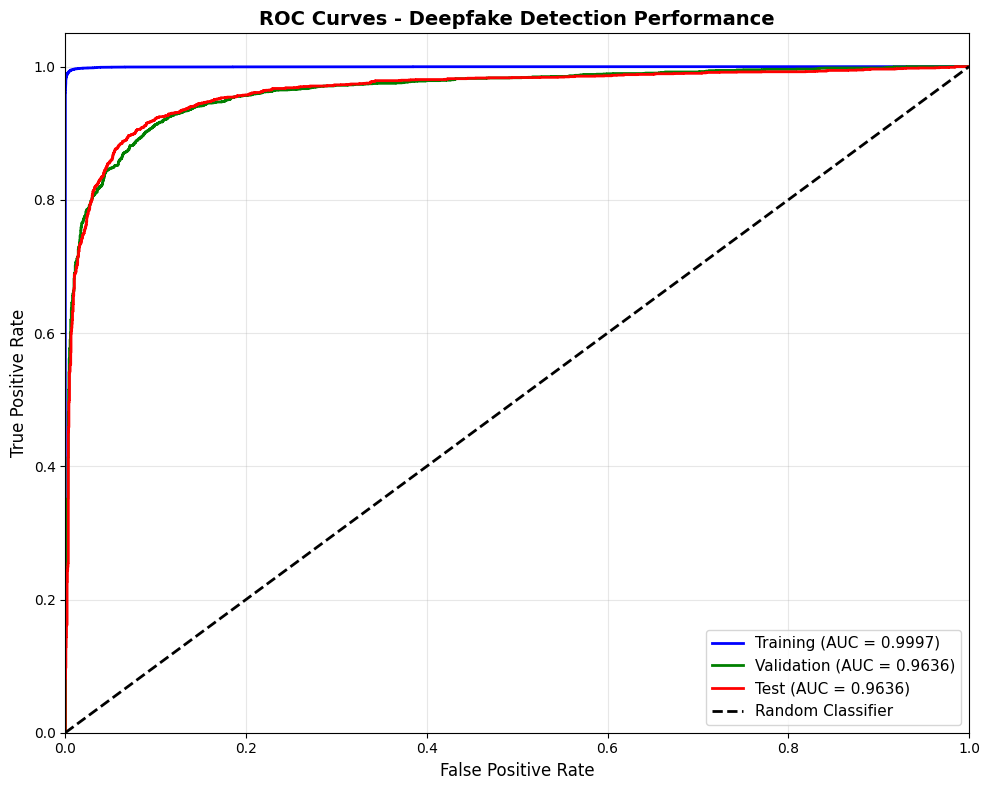

In [8]:
def main():
    print('Initializing fresh model, optimizer, and scheduler...')
    
    # 1. INSTANTIATE MODEL FRESH EVERY TIME (ALL LAYERS UNFROZEN)
    model = NoiseEfficientNet().to(device)
    
    print('✓ All layers unfrozen - entire model is trainable')
    print('✓ INVERTED 3-Tier Differential Learning Rates:')
    print('  - Early features (blocks 0-4): lr=1e-4 (fast adaptation to noise)')
    print('  - Late features (blocks 5+): lr=5e-5')
    print('  - Classifier: lr=1e-4')
    
    # 2. SETUP OPTIMIZER & SCHEDULER FRESH EVERY TIME
    criterion = nn.BCEWithLogitsLoss()
    
    # INVERTED 3-Tier Differential Learning Rates
    # Early layers need to adapt faster to truncated noise (not RGB textures)
    early_features_params = []
    late_features_params = []
    
    for i, block in enumerate(model.efficientnet.features):
        if i <= 4:
            early_features_params.extend(list(block.parameters()))
        else:
            late_features_params.extend(list(block.parameters()))
    
    optimizer = optim.AdamW([
        {'params': early_features_params, 'lr': 1e-4},    # Fast adaptation to noise
        {'params': late_features_params, 'lr': 5e-5},     # Moderate adaptation
        {'params': model.efficientnet.classifier.parameters(), 'lr': 1e-4}  # Task-specific head
    ], weight_decay=0.05)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5, 
        verbose=True, min_lr=1e-7
    )

    # 3. SETUP SAVING DIRECTORIES
    save_dir = Path('../saved_models')
    save_dir.mkdir(parents=True, exist_ok=True)
    best_model_path = save_dir / 'best_noise_efficientnet.pth'

    # 4. RESET TRAINING HISTORY
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
    best_val_auc = 0.0
    best_epoch = 0

    print('\nStarting training with 100% GPU-accelerated pipeline...\n')

    early_stop_patience = 10
    epochs_no_improve = 0

    for epoch in range(NUM_EPOCHS):
        print(f'Epoch {epoch+1}/{NUM_EPOCHS}')
        print('-' * 50)
        
        # Train (no mean/std arguments)
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, srm_layer)
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%')
        
        # Validate (no mean/std arguments)
        val_loss, val_acc, val_auc = validate_epoch(model, val_loader, criterion, device, srm_layer)
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%, Val AUC: {val_auc:.4f}')
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)
        
        # Learning rate scheduler step (monitors validation AUC)
        scheduler.step(val_auc)
        
        # Save best model based on AUC
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_epoch = epoch + 1
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
                'val_auc': val_auc,
            }, best_model_path)
            print(f'Best model saved (val_auc: {val_auc:.4f})')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        if epochs_no_improve >= early_stop_patience:
            print(f'\nEarly stopping triggered after {epoch+1} epochs!')
            break
        
        print()

    print(f'\nTraining completed!')
    print(f'Best model at epoch {best_epoch} with val_auc: {best_val_auc:.4f}')
    print(f'Model saved to: {best_model_path}')
    
    # Load best model weights
    print(f'\nLoading best model weights for final evaluation...')
    model.load_state_dict(torch.load(best_model_path)['model_state_dict'])
    print(f'✓ Best model loaded from epoch {best_epoch}')
    
    # Final Test Evaluation (no mean/std arguments)
    print(f'\n{"="*80}')
    print(f'FINAL TEST SET EVALUATION')
    print(f'{"="*80}')
    
    test_metrics = compute_detailed_metrics(model, test_loader, device, srm_layer, "Test")
    print_performance_summary(test_metrics, "Test")
    
    # Compute train and val metrics for comparison (no mean/std arguments)
    print(f'\nComputing training and validation metrics for comparison...')
    train_metrics = compute_detailed_metrics(model, train_loader, device, srm_layer, "Train")
    val_metrics = compute_detailed_metrics(model, val_loader, device, srm_layer, "Validation")
    
    print_performance_summary(train_metrics, "Training")
    print_performance_summary(val_metrics, "Validation")
    
    # Plot ROC curves
    plot_roc_curves(train_metrics, val_metrics, test_metrics)
    
    return history, best_model_path, train_metrics, val_metrics, test_metrics

if __name__ == '__main__':
    history, best_model_path, train_metrics, val_metrics, test_metrics = main()

## Step 8: Visualize Training History

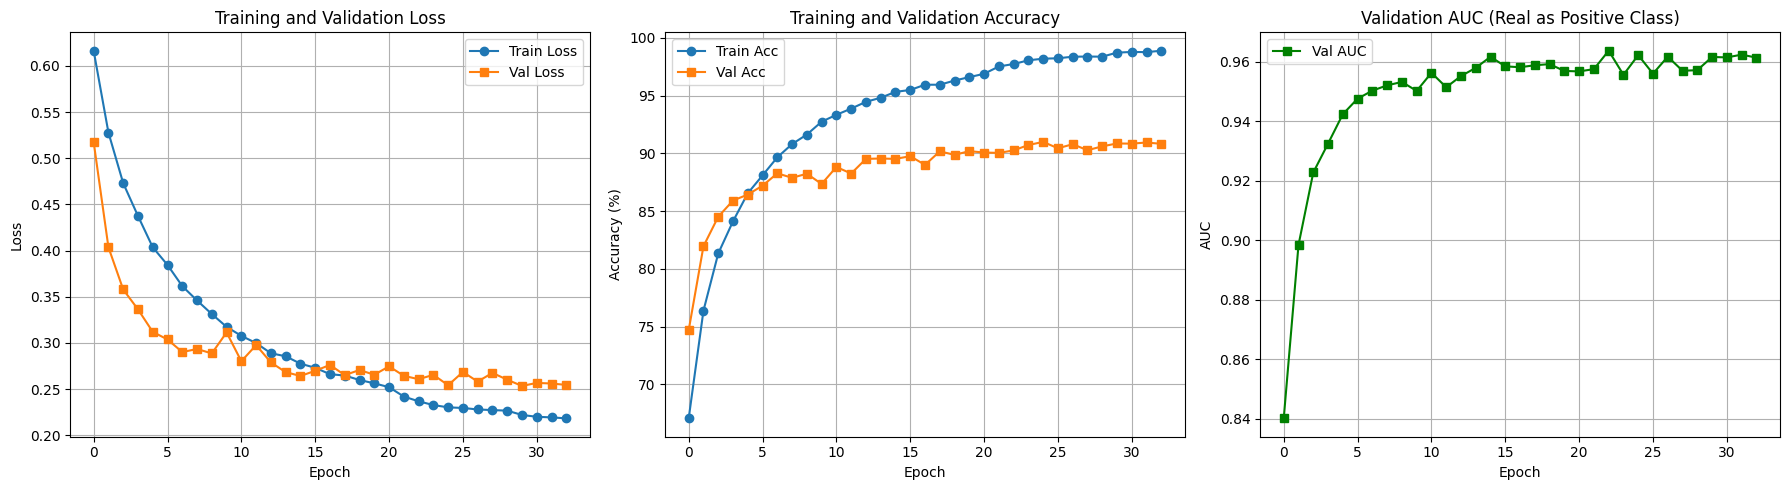

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Plot accuracy
axes[1].plot([acc * 100 for acc in history['train_acc']], label='Train Acc', marker='o')
axes[1].plot([acc * 100 for acc in history['val_acc']], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

# Plot AUC
axes[2].plot(history['val_auc'], label='Val AUC', marker='s', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].set_title('Validation AUC (Real as Positive Class)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()